## 1) Importação de bibliotecas

In [1]:
from sklearn.datasets import load_diabetes
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
import polars as pl

## 2) Leitura da base de dados

In [2]:
data = load_diabetes(as_frame = True, scaled = False)

data = pl.DataFrame(data.frame)

print(data.shape)
data.head(2)

(442, 11)


age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0


## 3) Analisando a tabela

### 3.1) Correlações

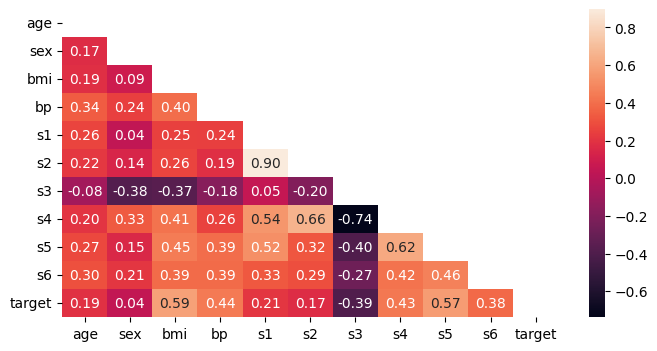

In [3]:
fig, ax = plt.subplots(
    figsize = (8, 4)
)

sns.heatmap(
    data = data.corr(),
    ax = ax,
    mask = np.triu(data.corr()),
    fmt = ".2f",
    annot = True,
    xticklabels = data.columns,
    yticklabels = data.columns
)

plt.show()

### 3.2) Pair plot

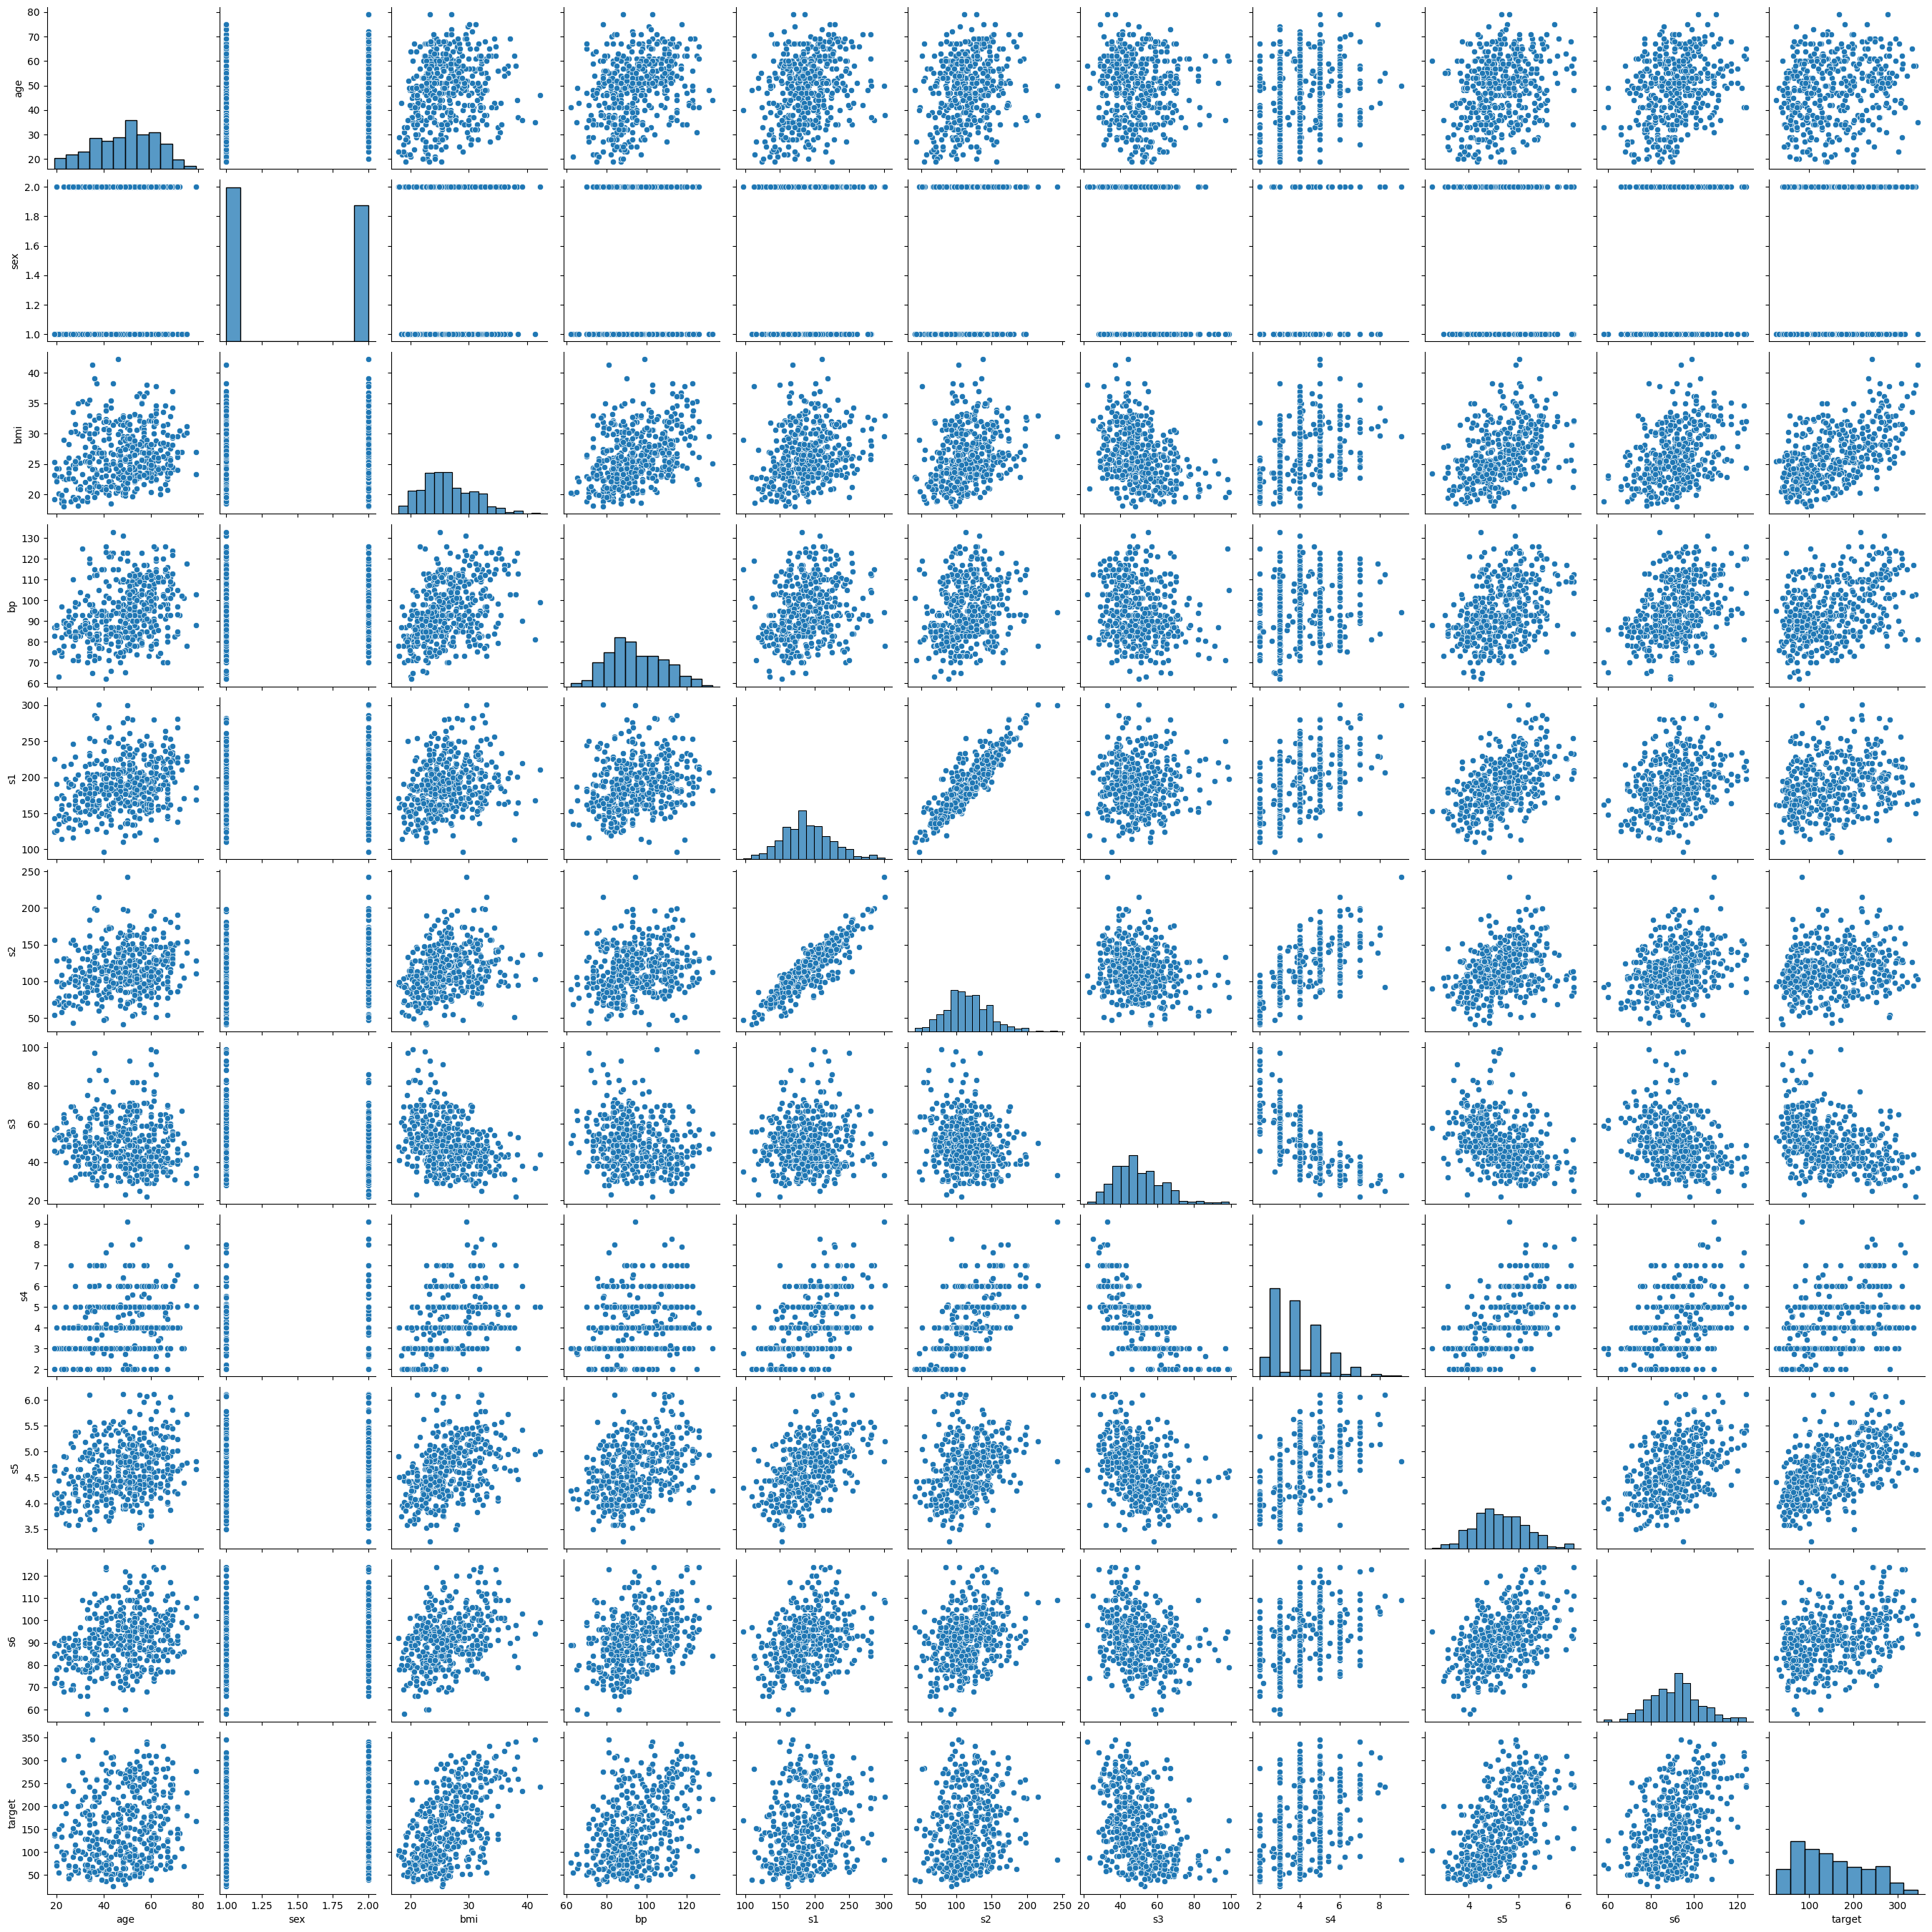

In [4]:
sns.pairplot(
    data = data.to_pandas()
)

plt.show()

### 3.3) Diminuindo dimensões

In [5]:
# data =
integer_columns = ["age", "sex"]
float_columns = ["bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6", "target"]

data = data.with_columns(
    [pl.col(column).cast(pl.Int8) for column in integer_columns],
)

data = data.with_columns(
    [pl.col(column).cast(pl.Float32) for column in float_columns],
)

print(data.shape)
data.head(2)

(442, 11)


age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32
59,2,32.099998,101.0,157.0,93.199997,38.0,4.0,4.8598,87.0,151.0
48,1,21.6,87.0,183.0,103.199997,70.0,3.0,3.8918,69.0,75.0


## 4) Salvando em formato `.parquet`

In [6]:
data.write_parquet(
    file = "./diabetes_dataset.parquet"
)